# Classification bois/cuivre — Fine-tuning ResNet50

**Projet** : Gallica Images — Classification gravures sur bois vs cuivre  
**Date**   : Avril 2026

Ce notebook entraîne un classifieur ResNet50 binaire bois/cuivre.
Il est conçu pour être relancé facilement pour une nouvelle version
— il suffit de changer `VERSION` et `CHEMIN_PTH`.

**Entrée**  : `data/datasets/bois_cuivre/train|val|test/bois|cuivre/`  
**Sortie**  : `modeles/bois_cuivre/resnet50_vN.pth` + matrice de confusion

⚠️ **Note mémoire** : Ne pas charger YOLO avant ce notebook — risque d'OOM GPU.
Si YOLO est en mémoire, faire Kernel → Restart avant de lancer ce notebook.

---

## 1. Configuration

**Seule cellule à modifier** pour entraîner une nouvelle version du modèle.

In [1]:
# ── Paramètres — à modifier pour chaque version ─────────────
VERSION    = "v2"                                          # ex: v1, v2, v3
CHEMIN_PTH = f"../../../modeles/bois_cuivre/resnet50_{VERSION}.pth"
CHEMIN_MC  = f"../../../resultats/classification/bois_cuivre/matrice_confusion_{VERSION}.png"

DOSSIER_DATASET = "../../../data/datasets/bois_cuivre"
N_EPOCHS        = 20
BATCH_SIZE      = 16
LR              = 1e-4
STEP_LR         = 5
GAMMA_LR        = 0.5
# ────────────────────────────────────────────────────────────

import sys
sys.path.insert(0, "..")
from gallica_utils import TRANSFORM_TRAIN, TRANSFORM_VAL, DEVICE

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models
from torch.utils.data import DataLoader

os.makedirs("../../../modeles/bois_cuivre", exist_ok=True)
os.makedirs("../../../resultats/classification/bois_cuivre", exist_ok=True)

device = DEVICE
print(f"Device  : {device}")
print(f"Version : {VERSION}")
print(f"Sortie  : {CHEMIN_PTH}")

Device  : cuda
Version : v2
Sortie  : ../../../modeles/bois_cuivre/resnet50_v2.pth


## 2. Chargement du dataset

In [2]:
train_dataset = datasets.ImageFolder(f"{DOSSIER_DATASET}/train", transform=TRANSFORM_TRAIN)
val_dataset   = datasets.ImageFolder(f"{DOSSIER_DATASET}/val",   transform=TRANSFORM_VAL)
test_dataset  = datasets.ImageFolder(f"{DOSSIER_DATASET}/test",  transform=TRANSFORM_VAL)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Classes : {train_dataset.classes}")
print(f"Train   : {len(train_dataset)} | Val : {len(val_dataset)} | Test : {len(test_dataset)}")

Classes : ['bois', 'cuivre']
Train   : 1052 | Val : 112 | Test : 115


## 3. Initialisation du modèle

In [3]:
modele = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
modele.fc = nn.Linear(modele.fc.in_features, 2)
modele     = modele.to(device)

# Class weights — compense le déséquilibre bois/cuivre
nb_b    = len(os.listdir(f"{DOSSIER_DATASET}/train/bois"))
nb_c    = len(os.listdir(f"{DOSSIER_DATASET}/train/cuivre"))
total_w = nb_b + nb_c
weights = torch.tensor([total_w/nb_b, total_w/nb_c]).to(device)
print(f"Class weights : bois={weights[0]:.2f}, cuivre={weights[1]:.2f}")

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(modele.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=STEP_LR, gamma=GAMMA_LR)

Class weights : bois=1.75, cuivre=2.34


## 4. Entraînement

In [4]:
meilleur_acc = 0.0

for epoch in range(N_EPOCHS):
    # ── Train ────────────────────────────────────────────────
    modele.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(modele(images), labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # ── Val ──────────────────────────────────────────────────
    modele.eval()
    val_loss = correct = total_v = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs  = modele(images)
            val_loss += criterion(outputs, labels).item()
            _, pred  = torch.max(outputs, 1)
            correct  += (pred == labels).sum().item()
            total_v  += labels.size(0)

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)
    val_acc     = correct / total_v

    marque = ""
    if val_acc > meilleur_acc:
        meilleur_acc = val_acc
        torch.save(modele.state_dict(), CHEMIN_PTH)
        marque = " ✓ sauvegardé"

    print(f"  Époque {epoch+1:2d}/{N_EPOCHS} | train={train_loss:.4f} | val={val_loss:.4f} | acc={val_acc:.4f}{marque}")
    scheduler.step()

print(f"\n✓ Terminé — meilleur val_acc = {meilleur_acc:.4f}")
print(f"✓ Modèle sauvegardé : {CHEMIN_PTH}")

  Époque  1/20 | train=0.0887 | val=0.0043 | acc=1.0000 ✓ sauvegardé
  Époque  2/20 | train=0.0181 | val=0.0008 | acc=1.0000
  Époque  3/20 | train=0.0082 | val=0.0047 | acc=1.0000
  Époque  4/20 | train=0.0095 | val=0.0057 | acc=1.0000
  Époque  5/20 | train=0.0331 | val=0.0012 | acc=1.0000
  Époque  6/20 | train=0.0036 | val=0.0007 | acc=1.0000
  Époque  7/20 | train=0.0007 | val=0.0001 | acc=1.0000
  Époque  8/20 | train=0.0009 | val=0.0001 | acc=1.0000
  Époque  9/20 | train=0.0008 | val=0.0001 | acc=1.0000
  Époque 10/20 | train=0.0009 | val=0.0002 | acc=1.0000
  Époque 11/20 | train=0.0003 | val=0.0003 | acc=1.0000
  Époque 12/20 | train=0.0002 | val=0.0002 | acc=1.0000
  Époque 13/20 | train=0.0028 | val=0.0006 | acc=1.0000
  Époque 14/20 | train=0.0018 | val=0.0001 | acc=1.0000
  Époque 15/20 | train=0.0005 | val=0.0001 | acc=1.0000
  Époque 16/20 | train=0.0003 | val=0.0001 | acc=1.0000
  Époque 17/20 | train=0.0002 | val=0.0001 | acc=1.0000
  Époque 18/20 | train=0.0004 | val

## 5. Évaluation sur le test set

              precision    recall  f1-score   support

        bois       0.97      1.00      0.99        66
      cuivre       1.00      0.96      0.98        49

    accuracy                           0.98       115
   macro avg       0.99      0.98      0.98       115
weighted avg       0.98      0.98      0.98       115



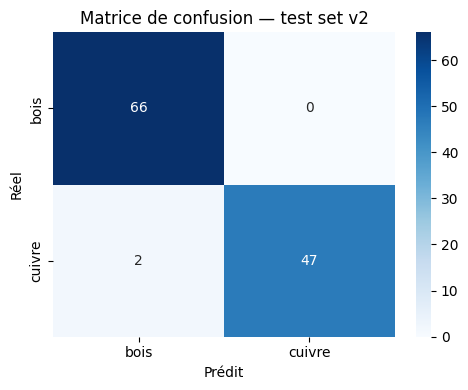

✓ Matrice de confusion sauvegardée : ../../../resultats/classification/bois_cuivre/matrice_confusion_v2.png


In [5]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

modele.load_state_dict(torch.load(CHEMIN_PTH, map_location=device))
modele.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        _, pred = torch.max(modele(images.to(device)), 1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=["bois", "cuivre"]))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["bois", "cuivre"],
            yticklabels=["bois", "cuivre"])
ax.set_xlabel("Prédit")
ax.set_ylabel("Réel")
ax.set_title(f"Matrice de confusion — test set {VERSION}")
plt.tight_layout()
plt.savefig(CHEMIN_MC, dpi=100)
plt.show()
print(f"✓ Matrice de confusion sauvegardée : {CHEMIN_MC}")